# House Price Prediction: Impact of Missing Value Imputation

## Project Overview

This project explores different techniques for handling missing values in a real-world-inspired house price dataset.

The dataset contains property-related features such as area, number of bedrooms and bathrooms, house age, distance from the city, parking spaces, nearby schools, and crime rate. The objective is to predict the **House Price** using these features.

Missing values are intentionally present in several predictor variables to study how different imputation techniques affect the performance of a machine learning model.

### Objectives

- Identify and analyze missing values in the dataset.
- Understand the impact of missing data on machine learning models.
- Apply **Univariate Imputation** using statistical measures such as mean and median.
- Apply **Multivariate Imputation** using information from multiple features.
- Compare model performance before and after imputation.
- Understand how the choice of imputation technique can affect predictive performance.

### Model Used

**Linear Regression** is used as the machine learning algorithm because House Price is a continuous numerical target.

### Evaluation Metrics

The models will be evaluated using:

- **R² Score** — measures how well the model explains the variation in house prices.
- **RMSE (Root Mean Squared Error)** — measures the average magnitude of prediction errors.

### Experiment

The project compares different approaches to understand which imputation strategy provides better predictive performance.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

LOADING THE DATASET

In [3]:
data=pd.read_csv('house_price_imputation_dataset.csv')
data

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate,House_Price
0,NaN,2.0,2.0,19.0,8.7,2.0,1.0,6.0,7.1,336000
1,1388.0,2.0,NaN,11.0,2.8,3.0,10.0,5.0,4.7,352000
2,NaN,NaN,3.0,17.0,9.6,1.0,8.0,7.0,3.9,375000
3,2135.0,4.0,NaN,15.0,5.4,2.0,0.0,5.0,5.9,499000
4,1345.0,2.0,NaN,23.0,NaN,2.0,8.0,4.0,0.5,385000
...,...,...,...,...,...,...,...,...,...,...
295,1138.0,2.0,2.0,9.0,3.7,1.0,6.0,3.0,3.2,335000
296,1855.0,3.0,2.0,13.0,11.8,1.0,0.0,3.0,2.9,385000
297,1588.0,2.0,1.0,18.0,14.8,-0.0,10.0,3.0,2.0,257000
298,1816.0,3.0,3.0,21.0,7.6,1.0,NaN,4.0,3.5,361000


In [4]:
data.head()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate,House_Price
0,NaN,2.0,2.0,19.0,8.7,2.0,1.0,6.0,7.1,336000
1,1388.0,2.0,NaN,11.0,2.8,3.0,10.0,5.0,4.7,352000
2,NaN,NaN,3.0,17.0,9.6,1.0,8.0,7.0,3.9,375000
3,2135.0,4.0,NaN,15.0,5.4,2.0,0.0,5.0,5.9,499000
4,1345.0,2.0,NaN,23.0,NaN,2.0,8.0,4.0,0.5,385000


UNDERSTANDING THE DATASET

In [5]:
data.shape

(300, 10)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            270 non-null    float64
 1   Bedrooms             276 non-null    float64
 2   Bathrooms            270 non-null    float64
 3   Age_of_House         279 non-null    float64
 4   Distance_to_City_km  273 non-null    float64
 5   Parking_Spaces       276 non-null    float64
 6   Floor_Number         282 non-null    float64
 7   Nearby_Schools       270 non-null    float64
 8   Crime_Rate           276 non-null    float64
 9   House_Price          300 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 23.6 KB


In [7]:
data.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate,House_Price
count,270.000000,276.000000,270.000000,279.000000,273.000000,276.000000,282.000000,270.000000,276.000000,300.000000
mean,1445.022222,2.684783,1.870370,17.634409,8.454945,1.532609,5.163121,4.651852,4.505435,315626.666667
std,443.587621,1.022610,0.777143,11.182706,3.820637,0.883601,3.248047,1.799705,1.761159,106429.498178
min,600.000000,1.000000,1.000000,1.000000,1.000000,-0.000000,0.000000,1.000000,0.500000,100000.000000
25%,1132.500000,2.000000,1.000000,9.000000,5.900000,1.000000,2.000000,3.000000,3.375000,246750.000000
50%,1473.500000,3.000000,2.000000,15.000000,8.100000,2.000000,5.000000,5.000000,4.600000,320500.000000
75%,1722.250000,3.000000,2.000000,23.000000,11.100000,2.000000,8.000000,6.000000,5.700000,383000.000000
max,3184.000000,6.000000,4.000000,50.000000,20.800000,4.000000,10.000000,10.000000,8.500000,702000.000000


In [8]:
#Checking for missing values 
data.isnull().sum()

Area_sqft              30
Bedrooms               24
Bathrooms              30
Age_of_House           21
Distance_to_City_km    27
Parking_Spaces         24
Floor_Number           18
Nearby_Schools         30
Crime_Rate             24
House_Price             0
dtype: int64

In [9]:
#Missing value percentage
(data.isnull().sum()/len(data))*100

Area_sqft              10.0
Bedrooms                8.0
Bathrooms              10.0
Age_of_House            7.0
Distance_to_City_km     9.0
Parking_Spaces          8.0
Floor_Number            6.0
Nearby_Schools         10.0
Crime_Rate              8.0
House_Price             0.0
dtype: float64

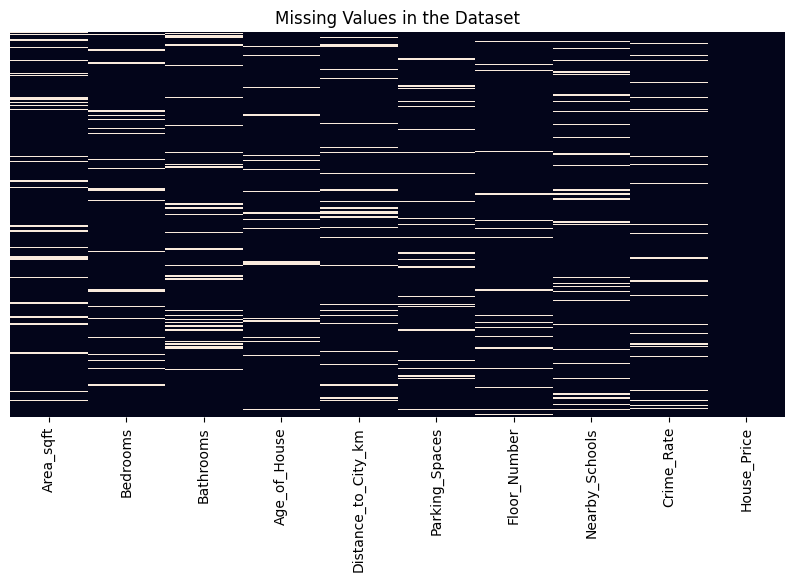

In [10]:
#Graphical Representation of the missing values
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(),cbar=False,yticklabels=False)

plt.title("Missing Values in the Dataset")
plt.show()

In [11]:
#Checking for missing values
duplicates=data.duplicated().sum()
print("Duplicates present in the dataset are =",duplicates)

Duplicates present in the dataset are = 0


SEPERATING FEATURES AND TARGET

In [12]:
x=data.drop('House_Price',axis=1)
y=data['House_Price']

In [13]:
x.sample(10)

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
271,804.0,3.0,1.0,11.0,11.4,1.0,6.0,4.0,5.0
258,1650.0,3.0,2.0,7.0,9.4,1.0,5.0,NaN,6.1
179,2674.0,6.0,4.0,NaN,2.2,2.0,3.0,2.0,6.1
6,NaN,5.0,3.0,18.0,13.0,2.0,9.0,7.0,0.5
234,2415.0,4.0,3.0,5.0,12.9,3.0,7.0,3.0,4.2
196,1052.0,1.0,1.0,20.0,16.3,2.0,10.0,NaN,4.1
89,1681.0,3.0,2.0,21.0,1.0,2.0,3.0,5.0,5.1
169,1111.0,2.0,NaN,8.0,1.7,4.0,8.0,4.0,5.3
99,1344.0,NaN,2.0,21.0,15.1,-0.0,5.0,5.0,2.0
107,1529.0,3.0,3.0,NaN,12.9,2.0,10.0,4.0,2.0


In [14]:
y.sample(10)

246    260000
12     328000
124    310000
253    354000
197    383000
182    286000
91     500000
100    182000
114    205000
169    345000
Name: House_Price, dtype: int64

TRAIN-TEST SPLIT

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [16]:
x_train.head(10)

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
232,1471.0,3.0,NaN,16.0,14.5,NaN,8.0,6.0,2.1
59,1889.0,3.0,2.0,36.0,5.8,1.0,8.0,9.0,6.1
6,NaN,5.0,3.0,18.0,13.0,2.0,9.0,7.0,0.5
185,1771.0,2.0,2.0,22.0,13.1,1.0,6.0,8.0,5.6
173,1604.0,4.0,3.0,12.0,20.8,1.0,6.0,3.0,4.7
30,1179.0,2.0,1.0,37.0,7.5,1.0,NaN,1.0,2.9
22,NaN,2.0,2.0,5.0,5.7,1.0,0.0,NaN,NaN
256,2020.0,NaN,1.0,13.0,10.1,NaN,1.0,5.0,3.4
56,1072.0,2.0,1.0,12.0,12.1,2.0,0.0,4.0,5.5
186,1663.0,3.0,2.0,41.0,8.3,2.0,9.0,3.0,4.8


In [17]:
x_test.shape

(60, 9)

UNIVARIATE MEDIAN IMPUTATION

In [18]:
from sklearn.impute import SimpleImputer

In [19]:
#Identifying numerical columns
numerical_cols=x_train.columns
numerical_cols

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_of_House',
       'Distance_to_City_km', 'Parking_Spaces', 'Floor_Number',
       'Nearby_Schools', 'Crime_Rate'],
      dtype='object')

In [20]:
median_imputation=SimpleImputer(strategy='median')

In [21]:
#Fit on Training Data
median_imputation.fit(x_train)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[1428.5, 3. , 2. ,..., 5. , 5. , 4.7]"


In [22]:
#Transform Training and Test Data
x_train_median=median_imputation.transform(x_train)
x_test_median=median_imputation.transform(x_test)

In [23]:
x_train_median

array([[1.4710e+03, 3.0000e+00, 2.0000e+00, ..., 8.0000e+00, 6.0000e+00,
        2.1000e+00],
       [1.8890e+03, 3.0000e+00, 2.0000e+00, ..., 8.0000e+00, 9.0000e+00,
        6.1000e+00],
       [1.4285e+03, 5.0000e+00, 3.0000e+00, ..., 9.0000e+00, 7.0000e+00,
        5.0000e-01],
       ...,
       [2.2990e+03, 3.0000e+00, 1.0000e+00, ..., 4.0000e+00, 4.0000e+00,
        7.1000e+00],
       [2.0990e+03, 4.0000e+00, 2.0000e+00, ..., 2.0000e+00, 5.0000e+00,
        7.1000e+00],
       [1.2960e+03, 2.0000e+00, 1.0000e+00, ..., 5.0000e+00, 4.0000e+00,
        4.2000e+00]], shape=(240, 9))

In [24]:
#Convert Back to DataFrame
x_train_median=pd.DataFrame(x_train_median,columns=numerical_cols,index=x_train.index)
x_test_median=pd.DataFrame(x_test_median,columns=x_test.columns,index=x_test.index)

In [25]:
x_train_median.head() #Median Imputed 

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
232,1471.0,3.0,2.0,16.0,14.5,2.0,8.0,6.0,2.1
59,1889.0,3.0,2.0,36.0,5.8,1.0,8.0,9.0,6.1
6,1428.5,5.0,3.0,18.0,13.0,2.0,9.0,7.0,0.5
185,1771.0,2.0,2.0,22.0,13.1,1.0,6.0,8.0,5.6
173,1604.0,4.0,3.0,12.0,20.8,1.0,6.0,3.0,4.7


In [26]:
x_test_median.head() #Median Imputed

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
203,1924.0,4.0,2.0,12.0,9.7,1.0,9.0,5.0,3.4
266,2185.0,3.0,2.0,9.0,7.5,2.0,10.0,2.0,7.4
152,1144.0,1.0,1.0,25.0,8.1,1.0,4.0,4.0,1.3
9,1694.0,3.0,3.0,17.0,14.8,2.0,5.0,2.0,4.7
233,1157.0,1.0,1.0,2.0,6.7,1.0,10.0,2.0,8.5


In [27]:
#Verify Missing Values
x_train_median.isnull().sum() 

Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_of_House           0
Distance_to_City_km    0
Parking_Spaces         0
Floor_Number           0
Nearby_Schools         0
Crime_Rate             0
dtype: int64

In [28]:
x_test_median.isnull().sum()

Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_of_House           0
Distance_to_City_km    0
Parking_Spaces         0
Floor_Number           0
Nearby_Schools         0
Crime_Rate             0
dtype: int64

In [29]:
#TRAIN LINEAR REGRESSION MODEL

In [30]:
lr_median=LinearRegression()

In [31]:
lr_median.fit(x_train_median,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 158.42,16137.11,23356.53,..., 4141.61, 8235.75,-5560.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.085e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [32]:
y_pred_median=lr_median.predict(x_test_median)

In [104]:
#Evaluating R2 score
r2_median=r2_score(y_pred_median,y_test)
r2_median=r2_median*100
print("Median Imputed R2 score =",r2_median)

Median Imputed R2 score = 63.84789346482827


In [34]:
#Evaluating RMSE
rmse_median=np.sqrt(mean_squared_error(y_test,y_pred_median))
print("Median Imputed RMSE =",rmse_median)

Median Imputed RMSE = 50679.362643580585


UNIVARIATE MEAN IMPUTATION

In [35]:
mean_imputation=SimpleImputer(strategy='mean')

In [36]:
#Fit on training data
mean_imputation.fit(x_train)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[1430.38, 2.7 , 1.9 ,..., 5.2 , 4.74, 4.54]"


In [37]:
#Transform both training and test data
x_train_mean=mean_imputation.transform(x_train)
x_test_mean=mean_imputation.transform(x_test)

In [38]:
x_train_mean 

array([[1.47100000e+03, 3.00000000e+00, 1.89814815e+00, ...,
        8.00000000e+00, 6.00000000e+00, 2.10000000e+00],
       [1.88900000e+03, 3.00000000e+00, 2.00000000e+00, ...,
        8.00000000e+00, 9.00000000e+00, 6.10000000e+00],
       [1.43038426e+03, 5.00000000e+00, 3.00000000e+00, ...,
        9.00000000e+00, 7.00000000e+00, 5.00000000e-01],
       ...,
       [2.29900000e+03, 2.70319635e+00, 1.00000000e+00, ...,
        4.00000000e+00, 4.00000000e+00, 7.10000000e+00],
       [2.09900000e+03, 4.00000000e+00, 2.00000000e+00, ...,
        2.00000000e+00, 4.73953488e+00, 7.10000000e+00],
       [1.29600000e+03, 2.00000000e+00, 1.00000000e+00, ...,
        5.00000000e+00, 4.00000000e+00, 4.20000000e+00]], shape=(240, 9))

In [39]:
#Convert Back to DataFrame
x_train_mean=pd.DataFrame(x_train_mean,columns=numerical_cols,index=x_train.index) #Mean Imputed 
x_train_mean.head(10) 

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
232,1471.000000,3.000000,1.898148,16.0,14.5,1.536697,8.000000,6.000000,2.100000
59,1889.000000,3.000000,2.000000,36.0,5.8,1.000000,8.000000,9.000000,6.100000
6,1430.384259,5.000000,3.000000,18.0,13.0,2.000000,9.000000,7.000000,0.500000
185,1771.000000,2.000000,2.000000,22.0,13.1,1.000000,6.000000,8.000000,5.600000
173,1604.000000,4.000000,3.000000,12.0,20.8,1.000000,6.000000,3.000000,4.700000
30,1179.000000,2.000000,1.000000,37.0,7.5,1.000000,5.197368,1.000000,2.900000
22,1430.384259,2.000000,2.000000,5.0,5.7,1.000000,0.000000,4.739535,4.540909
256,2020.000000,2.703196,1.000000,13.0,10.1,1.536697,1.000000,5.000000,3.400000
56,1072.000000,2.000000,1.000000,12.0,12.1,2.000000,0.000000,4.000000,5.500000
186,1663.000000,3.000000,2.000000,41.0,8.3,2.000000,9.000000,3.000000,4.800000


In [40]:
x_test_mean=pd.DataFrame(x_test_mean,columns=numerical_cols,index=x_test.index) #Mean Imputed 
x_test_mean.head(10)

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
203,1924.000000,4.0,2.000000,12.0,9.700000,1.0,9.000000,5.000000,3.400000
266,2185.000000,3.0,2.000000,9.0,7.500000,2.0,10.000000,2.000000,7.400000
152,1144.000000,1.0,1.000000,25.0,8.460274,1.0,4.000000,4.000000,1.300000
9,1694.000000,3.0,3.000000,17.0,14.800000,2.0,5.000000,2.000000,4.540909
233,1157.000000,1.0,1.000000,2.0,6.700000,1.0,10.000000,2.000000,8.500000
226,1479.000000,2.0,1.898148,15.0,11.400000,1.0,5.197368,5.000000,4.800000
196,1052.000000,1.0,1.000000,20.0,16.300000,2.0,10.000000,4.739535,4.100000
109,1416.000000,3.0,3.000000,18.0,7.200000,3.0,8.000000,5.000000,3.500000
5,1345.000000,3.0,3.000000,50.0,10.300000,2.0,0.000000,7.000000,2.600000
175,1430.384259,3.0,1.000000,8.0,5.000000,1.0,7.000000,5.000000,3.200000


In [41]:
#Verify Missing Values
x_train_mean.isnull().sum()

Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_of_House           0
Distance_to_City_km    0
Parking_Spaces         0
Floor_Number           0
Nearby_Schools         0
Crime_Rate             0
dtype: int64

In [42]:
x_test_mean.isnull().sum()

Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_of_House           0
Distance_to_City_km    0
Parking_Spaces         0
Floor_Number           0
Nearby_Schools         0
Crime_Rate             0
dtype: int64

In [43]:
#TRAIN LINEAR REGRESSION MODEL

In [44]:
lr_mean=LinearRegression()

In [45]:
lr_mean.fit(x_train_mean,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 156.81,17746.56,22328.63,..., 4100.51, 8308.87,-5392.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.093e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [46]:
y_pred_mean=lr_mean.predict(x_test_mean)

In [105]:
#Evaluating R2 score
r2_mean=r2_score(y_pred_mean,y_test)
r2_mean=r2_mean*100
print("Median Imputed R2 score =",r2_mean)

Median Imputed R2 score = 63.96903943797051


In [48]:
#Evaluating RMSE
rmse_mean=np.sqrt(mean_squared_error(y_test,y_pred_mean))
print("Mean Imputed RMSE =",rmse_mean)

Mean Imputed RMSE = 51055.79298087494


UNIVARIATE RANDOM IMPUTATION

In [49]:
import random

In [50]:
x_train_random=x_train.copy()
x_test_random=x_test.copy()

In [51]:
def random_sample_imputation(train_data, test_data, column):
    
    # Get the non-missing values from the training column
    random_values = train_data[column].dropna()
    
    # Find missing values in train and test
    train_missing = train_data[column].isnull()
    test_missing = test_data[column].isnull()
    
    # Randomly select values from training data
    train_random = random_values.sample(train_missing.sum(),random_state=42).values
    test_random = random_values.sample(test_missing.sum(),random_state=42).values
    
    # Fill missing values
    train_data.loc[train_missing, column] = train_random
    test_data.loc[test_missing, column] = test_random
    
    return train_data, test_data

In [52]:
for column in x_train.columns:
    x_train_random, x_test_random = random_sample_imputation(x_train_random,x_test_random,column)

In [53]:
x_train_random.head()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
232,1471.0,3.0,2.0,16.0,14.5,2.0,8.0,6.0,2.1
59,1889.0,3.0,2.0,36.0,5.8,1.0,8.0,9.0,6.1
6,1011.0,5.0,3.0,18.0,13.0,2.0,9.0,7.0,0.5
185,1771.0,2.0,2.0,22.0,13.1,1.0,6.0,8.0,5.6
173,1604.0,4.0,3.0,12.0,20.8,1.0,6.0,3.0,4.7


In [54]:
x_test_random.head()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
203,1924.0,4.0,2.0,12.0,9.7,1.0,9.0,5.0,3.4
266,2185.0,3.0,2.0,9.0,7.5,2.0,10.0,2.0,7.4
152,1144.0,1.0,1.0,25.0,18.4,1.0,4.0,4.0,1.3
9,1694.0,3.0,3.0,17.0,14.8,2.0,5.0,2.0,6.1
233,1157.0,1.0,1.0,2.0,6.7,1.0,10.0,2.0,8.5


In [55]:
#Verify missing values for training data
print("Missing values after random sample imputation in Training data")
print(x_train_random.isnull().sum())

Missing values after random sample imputation in Training data
Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_of_House           0
Distance_to_City_km    0
Parking_Spaces         0
Floor_Number           0
Nearby_Schools         0
Crime_Rate             0
dtype: int64


In [56]:
#Verify missing values for test data
print("Missing values after random sample imputation in test data")
print(x_test_random.isnull().sum())

Missing values after random sample imputation in test data
Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_of_House           0
Distance_to_City_km    0
Parking_Spaces         0
Floor_Number           0
Nearby_Schools         0
Crime_Rate             0
dtype: int64


In [57]:
#TRAIN LINEAR REGRESSION MODEL

In [58]:
lr_random=LinearRegression()

In [59]:
lr_random.fit(x_train_random,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 140.94,20231.38,22736.57,..., 4424.14, 8722.21,-6308.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.084e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [60]:
y_pred_random=lr_random.predict(x_test_random)

In [106]:
#Evaluating R2 and RMSE score
r2_random = r2_score(y_test,y_pred_random)
r2_random=r2_random*100
rmse_random = np.sqrt(mean_squared_error(y_test,y_pred_random))

print("R2 Score:", r2_random)
print("RMSE:", rmse_random)

R2 Score: 70.68448371130263
RMSE: 51915.163527061304


MULTIVARIATE IMPUTATION

--ITERATIVE IMPUTATION

In [62]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [63]:
multivariate_imputer=IterativeImputer(max_iter=20,random_state=42)

In [64]:
#Fit on Training Data
multivariate_imputer.fit(x_train)

,"max_iter max_iter: int, default=10Maximum number of imputation rounds to perform before returning theimputations computed during the final round. A round is a singleimputation of each feature with missing values. The stopping criterionis met once `max(abs(X_t - X_{t-1}))/max(abs(X[known_vals])) < tol`,where `X_t` is `X` at iteration `t`. Note that early stopping is onlyapplied if `sample_posterior=False`.",20
,"random_state random_state: int, RandomState instance or None, default=NoneThe seed of the pseudo random number generator to use. Randomizesselection of estimator features if `n_nearest_features` is not `None`,the `imputation_order` if `random`, and the sampling from posterior if`sample_posterior=True`. Use an integer for determinism.See :term:`the Glossary <random_state>`.",42
,"estimator estimator: estimator object, default=BayesianRidge()The estimator to use at each step of the round-robin imputation.If `sample_posterior=True`, the estimator must support`return_std` in its `predict` method.",None
,"missing_values missing_values: int or np.nan, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"sample_posterior sample_posterior: bool, default=FalseWhether to sample from the (Gaussian) predictive posterior of thefitted estimator for each imputation. Estimator must support`return_std` in its `predict` method if set to `True`. Set to`True` if using `IterativeImputer` for multiple imputations.",False
,"tol tol: float, default=1e-3Tolerance of the stopping condition.",0.001
,"n_nearest_features n_nearest_features: int, default=NoneNumber of other features to use to estimate the missing values ofeach feature column. Nearness between features is measured usingthe absolute correlation coefficient between each feature pair (afterinitial imputation). To ensure coverage of features throughout theimputation process, the neighbor features are not necessarily nearest,but are drawn with probability proportional to correlation for eachimputed target feature. Can provide significant speed-up when thenumber of features is huge. If `None`, all features will be used.",None
,"initial_strategy initial_strategy: {'mean', 'median', 'most_frequent', 'constant'}, default='mean'Which strategy to use to initialize the missing values. Same as the`strategy` parameter in :class:`~sklearn.impute.SimpleImputer`.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen `strategy=""constant""`, `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types... versionadded:: 1.3",None
,"imputation_order imputation_order: {'ascending', 'descending', 'roman', 'arabic', 'random'}, default='ascending'The order in which the features will be imputed. Possible values:- `'ascending'`: From features with fewest missing values to most.- `'descending'`: From features with most missing values to fewest.- `'roman'`: Left to right.- `'arabic'`: Right to left.- `'random'`: A random order for each round.",'ascending'
,"skip_complete skip_complete: bool, default=FalseIf `True` then features with missing values during :meth:`transform`which did not have any missing values during :meth:`fit` will beimputed with the initial imputation method only. Set to `True` if youhave many features with no missing values at both :meth:`fit` and:meth:`transform` time to save compute.",False


In [65]:
#Transfrom both Training and Test data
x_train_ii=multivariate_imputer.transform(x_train)
x_test_ii=multivariate_imputer.transform(x_test)

In [66]:
x_train_ii

array([[1.47100000e+03, 3.00000000e+00, 2.14948421e+00, ...,
        8.00000000e+00, 6.00000000e+00, 2.10000000e+00],
       [1.88900000e+03, 3.00000000e+00, 2.00000000e+00, ...,
        8.00000000e+00, 9.00000000e+00, 6.10000000e+00],
       [2.21630905e+03, 5.00000000e+00, 3.00000000e+00, ...,
        9.00000000e+00, 7.00000000e+00, 5.00000000e-01],
       ...,
       [2.29900000e+03, 3.27018406e+00, 1.00000000e+00, ...,
        4.00000000e+00, 4.00000000e+00, 7.10000000e+00],
       [2.09900000e+03, 4.00000000e+00, 2.00000000e+00, ...,
        2.00000000e+00, 4.75182171e+00, 7.10000000e+00],
       [1.29600000e+03, 2.00000000e+00, 1.00000000e+00, ...,
        5.00000000e+00, 4.00000000e+00, 4.20000000e+00]], shape=(240, 9))

In [67]:
#Converting to Data Frames
x_train_ii=pd.DataFrame(x_train_ii,columns=numerical_cols,index=x_train.index)
x_test_ii=pd.DataFrame(x_test_ii,columns=numerical_cols,index=x_test.index)

In [68]:
x_train_ii.head() #Imputed

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
232,1471.000000,3.0,2.149484,16.0,14.5,1.54445,8.0,6.0,2.1
59,1889.000000,3.0,2.000000,36.0,5.8,1.00000,8.0,9.0,6.1
6,2216.309051,5.0,3.000000,18.0,13.0,2.00000,9.0,7.0,0.5
185,1771.000000,2.0,2.000000,22.0,13.1,1.00000,6.0,8.0,5.6
173,1604.000000,4.0,3.000000,12.0,20.8,1.00000,6.0,3.0,4.7


In [69]:
x_test_ii.head() #Imputed

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
203,1924.0,4.0,2.0,12.0,9.700000,1.0,9.0,5.0,3.400000
266,2185.0,3.0,2.0,9.0,7.500000,2.0,10.0,2.0,7.400000
152,1144.0,1.0,1.0,25.0,8.482498,1.0,4.0,4.0,1.300000
9,1694.0,3.0,3.0,17.0,14.800000,2.0,5.0,2.0,4.473351
233,1157.0,1.0,1.0,2.0,6.700000,1.0,10.0,2.0,8.500000


In [70]:
#TRAIN LINEAR REGRESSION MODEL

In [71]:
lr_ii=LinearRegression()

In [72]:
lr_ii.fit(x_train_ii,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 157.98,11094.79,23301.48,..., 3650.63, 8494.83,-4661.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.961e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [73]:
y_pred_ii=lr_ii.predict(x_test_ii)

In [103]:
#Evaluating R2 and RMSE score
r2_ii = r2_score(y_test,y_pred_ii)
r2_ii=r2_ii*100
rmse_ii = np.sqrt(mean_squared_error(y_test,y_pred_ii))

print("R2 Score:", r2_ii)
print("RMSE:", rmse_ii)

R2 Score: 70.4849212636685
RMSE: 52091.567467111425


--KNN IMPUTATION

In [75]:
from sklearn.impute import KNNImputer

In [76]:
knnimpute=KNNImputer()

In [77]:
#Fit on Training Data
knnimpute.fit(x_train)

,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.``None`` if add_indicator is False.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9


In [78]:
#Transform on both Training and Test Data
x_train_knn=knnimpute.transform(x_train)
x_test_knn=knnimpute.transform(x_test)

In [79]:
x_train_knn

array([[1.4710e+03, 3.0000e+00, 2.8000e+00, ..., 8.0000e+00, 6.0000e+00,
        2.1000e+00],
       [1.8890e+03, 3.0000e+00, 2.0000e+00, ..., 8.0000e+00, 9.0000e+00,
        6.1000e+00],
       [1.4492e+03, 5.0000e+00, 3.0000e+00, ..., 9.0000e+00, 7.0000e+00,
        5.0000e-01],
       ...,
       [2.2990e+03, 2.4000e+00, 1.0000e+00, ..., 4.0000e+00, 4.0000e+00,
        7.1000e+00],
       [2.0990e+03, 4.0000e+00, 2.0000e+00, ..., 2.0000e+00, 5.4000e+00,
        7.1000e+00],
       [1.2960e+03, 2.0000e+00, 1.0000e+00, ..., 5.0000e+00, 4.0000e+00,
        4.2000e+00]], shape=(240, 9))

In [80]:
#Convert to Data Frame
x_train_knn=pd.DataFrame(x_train_knn,columns=numerical_cols,index=x_train.index)
x_test_knn=pd.DataFrame(x_test_knn,columns=numerical_cols,index=x_test.index)

In [81]:
x_train_knn.head() #Imputed

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
232,1471.0,3.0,2.8,16.0,14.5,1.6,8.0,6.0,2.1
59,1889.0,3.0,2.0,36.0,5.8,1.0,8.0,9.0,6.1
6,1449.2,5.0,3.0,18.0,13.0,2.0,9.0,7.0,0.5
185,1771.0,2.0,2.0,22.0,13.1,1.0,6.0,8.0,5.6
173,1604.0,4.0,3.0,12.0,20.8,1.0,6.0,3.0,4.7


In [82]:
x_test_knn.head() #Imputed

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City_km,Parking_Spaces,Floor_Number,Nearby_Schools,Crime_Rate
203,1924.0,4.0,2.0,12.0,9.7,1.0,9.0,5.0,3.4
266,2185.0,3.0,2.0,9.0,7.5,2.0,10.0,2.0,7.4
152,1144.0,1.0,1.0,25.0,9.6,1.0,4.0,4.0,1.3
9,1694.0,3.0,3.0,17.0,14.8,2.0,5.0,2.0,3.2
233,1157.0,1.0,1.0,2.0,6.7,1.0,10.0,2.0,8.5


In [83]:
#TRAIN LINEAR REGRESSION MODEL

In [84]:
lr_knn=LinearRegression()

In [85]:
lr_knn.fit(x_train_knn,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 156.2 ,15543.03,24543.09,..., 4278.15, 7936.67,-5017.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area_sqft','Bedrooms','Bathrooms',...,'Floor_Number','Nearby_Schools', 'Crime_Rate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.087e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [86]:
y_pred_knn=lr_knn.predict(x_test_knn)

In [102]:
#Evaluating R2 and RMSE score
r2_knn = r2_score(y_test,y_pred_knn)
r2_knn=r2_knn*100

rmse_knn = np.sqrt(mean_squared_error(y_test,y_pred_knn))

print("R2 Score:", r2_knn)
print("RMSE:", rmse_knn)

R2 Score: 72.41885661060753
RMSE: 50356.041850201174


COMPARING THE RESULTS

In [107]:
results=pd.DataFrame({
    'Imputation Method':['Median Imputation','Mean Imputation','Random Imputation','Iterative Imputation','KNN Imputation'],
    'R2 Score':[r2_median,r2_mean,r2_random,r2_ii,r2_knn],
    'RMSE Score':[rmse_median,rmse_mean,rmse_random,rmse_ii,rmse_knn]
})
results

,Imputation Method,R2 Score,RMSE Score
0,Median Imputation,63.847893,50679.362644
1,Mean Imputation,63.969039,51055.792981
2,Random Imputation,70.684484,51915.163527
3,Iterative Imputation,70.484921,52091.567467
4,KNN Imputation,72.418857,50356.041850


In [108]:
results['R2 Score'].sort_values(ascending=False)

4    72.418857
2    70.684484
3    70.484921
1    63.969039
0    63.847893
Name: R2 Score, dtype: float64

In [109]:
results['RMSE Score'].sort_values(ascending=True)

4    50356.041850
0    50679.362644
1    51055.792981
2    51915.163527
3    52091.567467
Name: RMSE Score, dtype: float64

VISUALISING THE R2 AND RMSE

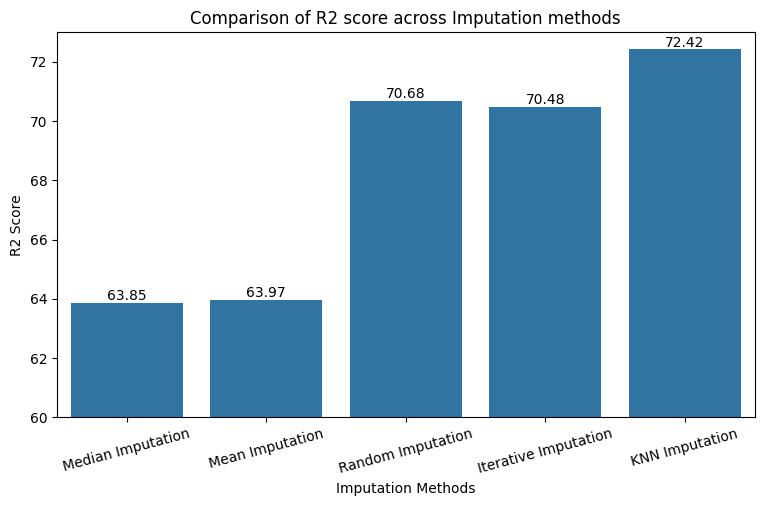

In [112]:
#R2 score
plt.figure(figsize=(9,5))
ax=sns.barplot(data=results,x='Imputation Method',y='R2 Score')

plt.title('Comparison of R2 score across Imputation methods')
plt.xlabel('Imputation Methods')
plt.ylabel('R2 Score')

plt.ylim(60,73)
for container in ax.containers:
    ax.bar_label(container,fmt='%.2f')

plt.xticks(rotation=15)
plt.show()

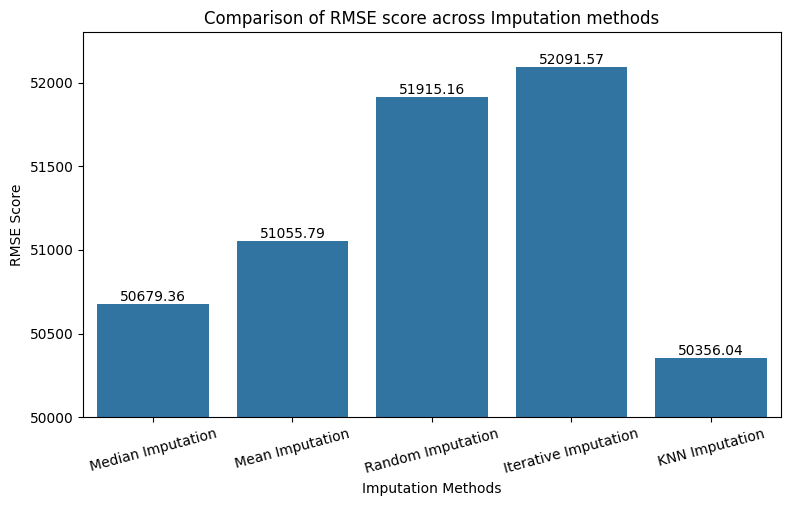

In [113]:
#RMSE score
plt.figure(figsize=(9,5))
ax=sns.barplot(data=results,x='Imputation Method',y='RMSE Score')

plt.title('Comparison of RMSE score across Imputation methods')
plt.xlabel('Imputation Methods')
plt.ylabel('RMSE Score')

plt.ylim(50000,52300)
for container in ax.containers:
    ax.bar_label(container,fmt='%.2f')
plt.xticks(rotation=15)
plt.show()

## Conclusion

1. **Missing Value Analysis:**  
   The dataset contained missing values across multiple numerical features, highlighting the importance of properly handling incomplete data before training a machine learning model.

2. **Univariate Imputation:**  
   Mean, Median, and Random Sample Imputation were applied by estimating missing values using information from the respective feature itself. These methods provided simple and effective approaches for handling missing data.

3. **Multivariate Imputation:**  
   KNN and Iterative Imputation were used to estimate missing values by considering relationships between multiple features. These approaches provided more information-based alternatives to traditional univariate techniques.

4. **Impact on Model Performance:**  
   The different imputation techniques produced different R² scores and RMSE values when evaluated using Linear Regression. This demonstrates that the choice of imputation strategy can directly influence machine learning model performance.

5. **Overall Learning:**  
   There is no universally best imputation technique. The appropriate method depends on the dataset, the distribution of the features, the pattern of missing values, and the relationships between variables. Comparing multiple approaches helps identify a suitable strategy for a given machine learning problem.